## Logistic Regression Tutorial Notebook

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('Cancer_data.csv')
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


### Step 2: Explore the Dataset

In [3]:
print("Shape od dataset",df.shape)
print()
print("Columns",df.columns)
print()
print("Missing Values",df.isnull().sum())

Shape od dataset (1500, 9)

Columns Index(['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity',
       'AlcoholIntake', 'CancerHistory', 'Diagnosis'],
      dtype='str')

Missing Values Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


In [31]:
df['Diagnosis'].value_counts(normalize=True)

Diagnosis
0    0.628667
1    0.371333
Name: proportion, dtype: float64

### Step 3: Define Features and Target Variable

In [8]:
X =df.drop("Diagnosis",axis = 1)
y =df["Diagnosis"]

In [10]:
print("Feature Shape:",X.shape)
print("Target Shape", y.shape)

Feature Shape: (1500, 8)
Target Shape (1500,)


### Step 4: Split the Dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1200, 8)
Testing Data Shape: (300, 8)


### Step 5: Create Logistic Regression Model

In [13]:
model = LogisticRegression(max_iter = 1500)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


### Step 6: Make Predictions

In [14]:
y_pred = model.predict(X_test)
print("Predicted Values :\n" , y_pred)

Predicted Values :
 [1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 1 1
 1 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 1 0 0 1 0 0 0 0 1 1
 1 0 1 1 0 0 0 0 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0
 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0
 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 1 0 1 0 0 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0
 0 0 1 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1
 0 0 0 0]


### Step 7: Evaluate the Model

In [15]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy Score:" , accuracy)

Accuracy Score: 0.86


### Step 8: Confusion Matrix

In [17]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[171  13]
 [ 29  87]]


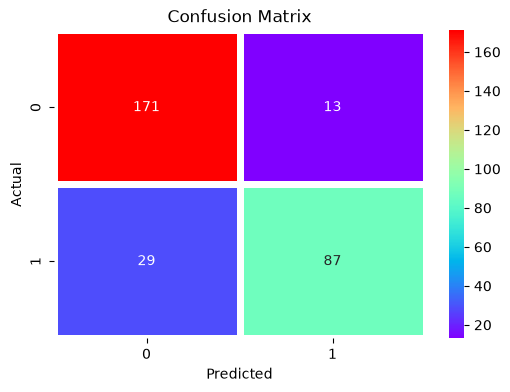

In [28]:

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='rainbow', linewidths=5, linecolor='white', 
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Step 9: Classification Report

In [30]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       184
           1       0.87      0.75      0.81       116

    accuracy                           0.86       300
   macro avg       0.86      0.84      0.85       300
weighted avg       0.86      0.86      0.86       300



In [ ]:
plt.subplot(2,2,1)
plt.plot([1,2,3],[4,5,6],marker="o")
plt.title("Plot 1")

plt.subplot(2,2,2)
plt.plot([1,3,5],[2,5,1],marker="s")
plt.title("Plot 2")

plt.subplot(2,2,3)
plt.plot([2,4,6],[1,2,5],marker="^")
plt.title("Plot 3")

plt.subplot(2,2,4)
plt.plot([3,2,5],[6,1,4],marker="v")
plt.title("Plot 4")

plt.tight_layout()
plt.show()